# CPU quickstart — synthetic cross-sample alignment

This self-contained notebook verifies a spAlignDE installation
without downloading external data. It creates a deterministic
two-sample AnnData object with three known shared structures, runs
pre-alignment, rasterization and a short S-LDDMM fit, and validates
the standardized output columns.

The data are synthetic and intended only for software validation;
do not use this example for biological interpretation. Full-scale
MERFISH, kidney and breast-cancer workflows are documented in the
cross-sample tutorial.


In [1]:
import numpy as np
import spAlignDE

print("spAlignDE", spAlignDE.__version__)


spAlignDE 0.1.0


## 1. Create a ready-to-align AnnData input

Real inputs require `obs["sample_id"]`, `obs["cluster"]`, unique
observation names and finite coordinates in `obsm["spatial"]`.
The helper below supplies that exact contract with known labels so
this quickstart can focus on alignment. Full workflows infer the
cluster labels in their preceding clustering notebook.


In [2]:
adata = spAlignDE.make_cross_sample_example(
    n_per_cluster=20,
    n_genes=12,
    random_state=0,
)
spAlignDE.validate_cross_sample_anndata(adata)
print(adata)
print(adata.obs.groupby(["sample_id", "cluster"], observed=True).size())


AnnData object with n_obs × n_vars = 120 × 12
    obs: 'sample_id', 'cluster'
    obsm: 'spatial'
sample_id  cluster
query      0          20
           1          20
           2          20
reference  0          20
           1          20
           2          20
dtype: int64


## 2. Run the alignment on CPU

Two optimization iterations keep the CI smoke test short. They are
not a scientific recommendation. Use the validated dataset-specific
profiles and the Parameter Tuning Guide for real tissue sections.


In [3]:
result = spAlignDE.align_cross_sample(
    adata,
    query_sample="query",
    reference_sample="reference",
    rasterization_config=spAlignDE.RasterizationConfig(
        grid_spacing=0.30,
    ),
    slddmm_config=spAlignDE.SLDDMMConfig(
        iterations=2,
        kernel_scale=1.0,
        velocity_grid_spacing=0.5,
        momentum_lr=1.0,
        minimum_momentum_lr=1.0,
        sigma_regularization=100.0,
    ),
    device="cpu",
    verbose=False,
    return_result=True,
)
print(result.metrics)


{'nearest_label_agreement_prealigned': 1.0, 'nearest_label_agreement_aligned': 1.0, 'nearest_label_agreement_gain': 0.0, 'elapsed_seconds': 0.2229757308959961, 'n_shared_clusters': 3, 'device': 'cpu'}


## 3. Validate and inspect the output

spAlignDE preserves `X`, observation order and the original
coordinates. It adds pre-aligned and aligned x/y columns to `obs`;
reference coordinates remain fixed.


In [4]:
required = list(spAlignDE.REQUIRED_OUTPUT_COLUMNS)
assert all(column in result.adata.obs for column in required)
assert result.adata.shape == adata.shape
assert np.array_equal(result.adata.X.toarray(), adata.X.toarray())

reference = result.adata.obs["sample_id"].astype(str) == "reference"
np.testing.assert_allclose(
    result.adata.obs.loc[reference, ["x_aligned", "y_aligned"]],
    adata.obsm["spatial"][reference],
)
result.adata.obs[["sample_id", "cluster", *required]].head()


,sample_id,cluster,x_prealigned,y_prealigned,x_aligned,y_aligned
cell_0,reference,0,0.022631,-0.023779,0.022631,-0.023779
cell_1,reference,0,0.115276,0.018882,0.115276,0.018882
cell_2,reference,0,-0.096420,0.065087,-0.096420,0.065087
cell_3,reference,0,0.234720,0.170475,0.234720,0.170475
cell_4,reference,0,-0.126672,-0.227776,-0.126672,-0.227776


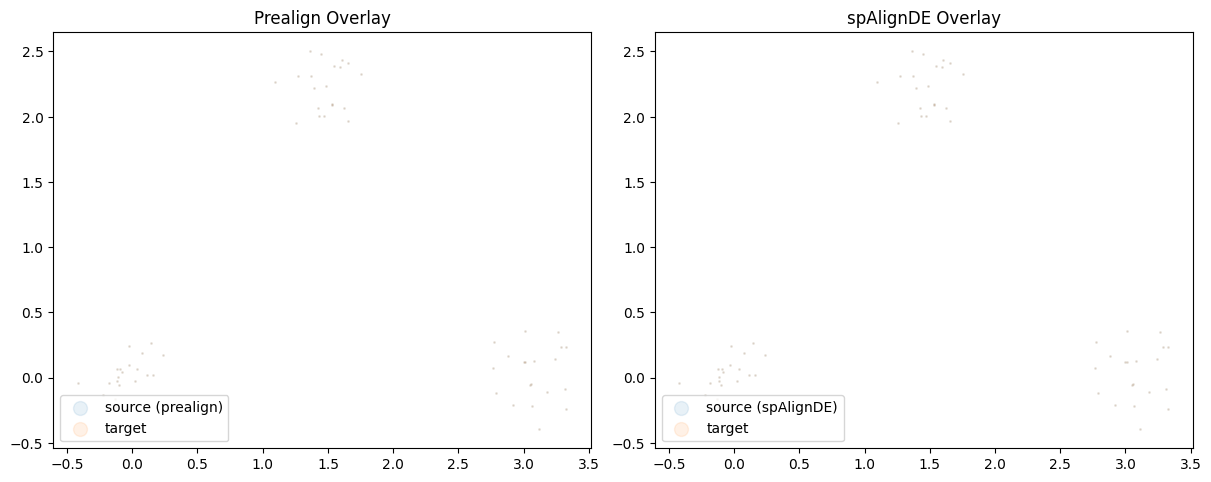

Text(0.5, 1.02, 'Synthetic query-to-reference quickstart')

In [5]:
figure, axes = spAlignDE.plot_alignment_result(result)
figure.suptitle("Synthetic query-to-reference quickstart", y=1.02)


## Next steps

Continue with the cross-sample tutorial to prepare public MERFISH
or Visium inputs, infer joint structures and use a full validated
S-LDDMM configuration. Save the aligned AnnData with
`result.adata.write_h5ad("aligned.h5ad")` when adapting this code.
